# Qual é o melhor plano?

A empresa de telecomunicações Megaline oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Iremos realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Temos dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Aqui, o trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

## Inicialização

In [1]:
# Carregando todas as bibliotecas
import pandas as pd                       # biblioteca pandas
import numpy as np                        # biblioteca numpy
from matplotlib import pyplot as plt      # Recursos gráficos da biblioteca matplotlib
import seaborn as sns                     # biblioteca gráfica seaborn
from scipy import stats as st             # Recursos estatisticos da biblioteca scipy

## Carregando os dados

In [2]:
# Carregando os arquivos de dados em diferentes DataFrames
users = pd.read_csv('../datasets/megaline_users.csv')           # Tabela de dados sobre usuários

calls = pd.read_csv('../datasets/megaline_calls.csv')           # Tabela de dados sobre as chamadas

messages = pd.read_csv('../datasets/megaline_messages.csv')     # Tabela de dados sobre mensagens de texto

internet = pd.read_csv('../datasets/megaline_internet.csv')     # Tabela de dados sobre sessões web

plans = pd.read_csv('../datasets/megaline_plans.csv')           # Tabela de dados sobre os planos


## Preparando os dados

## Planos

In [3]:
# Imprimindo informações gerais/resumo sobre o DataFrame dos planos
print(plans.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes
None


In [4]:
# Imprimindo uma amostra de dados dos planos
plans.sample(2)


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
1,1000,30720,3000,70,7,0.01,0.01,ultimate
0,50,15360,500,20,10,0.03,0.03,surf


Para uma melhor padronização, os dados das colunas 'usd_per_gb' e  'usd_monthly_pay' devem ser convertidos de int para o tipo float, já que trata-se de um valor monetário (pois no contexto geral é interpretado como uma variável contínua)

## Corrigindo os dados

In [5]:
# convertendo as colunas 'usd_per_gb' e 'usd_monthly_pay' de int para o tipo float:
plans['usd_per_gb'] = plans['usd_per_gb'].astype('float')

plans['usd_monthly_pay'] = plans['usd_monthly_pay'].astype('float')

# verificando se a conversão foi efetiva:
print(plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      float64
 4   usd_per_gb             2 non-null      float64
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(4), int64(3), object(1)
memory usage: 260.0+ bytes
None


Conversão efetuada com sucesso

## Enriquecendo os dados

É preciso renomear a coluna 'plan_name' para 'plan', para padronizar com as informações dos usuários:

In [6]:
# renomeando a coluna 'plan_name' para 'plan':
plans = plans.rename(columns = {'plan_name':'plan'})

## Usuários

In [7]:
# Imprimindo informações gerais/resumo sobre o DataFrame dos usuários
print(users.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


In [8]:
# Imprimindo uma amostra de dados dos usuários
users.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
97,1097,Deandre,Powell,27,"Washington-Arlington-Alexandria, DC-VA-MD-WV MSA",2018-02-26,surf,NaN
374,1374,Ching,Watts,55,"Louisville/Jefferson County, KY-IN MSA",2018-02-14,surf,NaN
197,1197,Lon,Parker,56,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-05,surf,NaN
42,1042,Clementina,Mclaughlin,40,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",2018-01-15,surf,NaN
379,1379,Jarrett,Spencer,34,"Grand Rapids-Kentwood, MI MSA",2018-10-18,surf,NaN


A coluna 'user_id', por ser apenas uma descrição de um dado, deve ser convertida para o tipo object, de modo a evitar possiveis problemas em junções de dataframes futuras. Além disso, é mais útil converter as colunas 'churn_date' e 'reg_date' para o tipo datetime, já que tratam-se de datas. Temos também muitos valores ausentes na coluna 'churn_date', o que é um fato normal: Pois sugere que a maioria dos usuários ainda estavam ativos no momento da coleta de dados.

### Corrigindo os dados

In [9]:
# Convertendo as colunas 'churn_date' e 'reg_date' para o tipo datetime:
users['reg_date'] = pd.to_datetime(users['reg_date'],format = '%Y-%m-%d')

users['churn_date'] = pd.to_datetime(users['churn_date'],format = '%Y-%m-%d')

# Convertendo 'user_id' para object:
users['user_id'] = users['user_id'].astype('str')

# verificando se a conversão foi efetivada: 
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    object        
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(5)
memory usage: 31.4+ KB


### Enriquecendo os dados

In [10]:
# não há necessidade

## Chamadas

In [11]:
# Imprimindo informações gerais/resumo sobre o DataFrame das chamadas
calls.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [12]:
# Imprimindo uma amostra de dados das chamadas
calls.sample(5)


,id,user_id,call_date,duration
108045,1382_1096,1382,2018-11-10,2.02
53509,1192_431,1192,2018-10-18,0.00
28801,1109_428,1109,2018-06-19,0.00
7030,1033_46,1033,2018-10-13,17.30
33982,1126_922,1126,2018-12-03,0.00


Devemos converter 'user_id' para object, e 'call_date' para datetime. Além disso, os valores da coluna 'duration' devem ser arredondados para o maior inteiro mais próximo, e em seguida convertida para int (faremos isso criando uma nova coluna chamada 'duration_arredondada', para não perder os dados da original)

### Corrigindo os dados

In [13]:
# Convertendo a coluna 'user_id' para object:
calls['user_id'] = calls['user_id'].astype('str')

# Convertendo a coluna 'call_date' para datetime:
calls['call_date'] = pd.to_datetime(calls['call_date'],format = '%Y-%m-%d')

# Arredondando os valores da coluna 'duration' para o maior inteiro mais próximo:
def maior_inteiro(tempo):
    parte_fracionaria = tempo - int(tempo) # verifica qual é a parte fracionária do tempo. Ex.: a parte fracionária de 7.54 é 0.54
    if parte_fracionaria > 0: 
        imagem = int(tempo) + 1 # caso exista parte fracionária, arredonda o tempo para o maior inteiro (próximo minuto)
    else: 
        imagem = tempo # caso não exista parte fracionária, o tempo não é alterado
    return imagem

calls['duration_arredondada'] = calls['duration'].apply(maior_inteiro) # arredondando os valores da coluna 'duration' para o maior inteiro mais próximo

# Convertendo 'duration_arredondada' para int:
calls['duration_arredondada'] = calls['duration_arredondada'].astype('int')

# Verificando as conversões:
calls.info()

# Verificando o resultado do arredondamento:
calls.sample(5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   id                    137735 non-null  object        
 1   user_id               137735 non-null  object        
 2   call_date             137735 non-null  datetime64[ns]
 3   duration              137735 non-null  float64       
 4   duration_arredondada  137735 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 5.3+ MB


,id,user_id,call_date,duration,duration_arredondada
60761,1220_116,1220,2018-09-07,6.67,7
116583,1408_232,1408,2018-03-10,10.74,11
93931,1335_161,1335,2018-09-04,9.38,10
136900,1496_69,1496,2018-10-19,0.00,0
110749,1390_198,1390,2018-06-18,8.23,9


### Enriquecendo os dados

Precisamos incluir uma coluna 'mes', para futuramente calcular a quantidade de chamadas realizadas por usuarios por mês.

In [14]:
# criando uma coluna 'mes' para a tabela 'calls':
calls['mes'] = calls['call_date'].dt.month
calls.sample(5)

,id,user_id,call_date,duration,duration_arredondada,mes
102516,1363_129,1363,2018-10-04,7.79,8,10
67522,1242_18,1242,2018-10-11,0.00,0,10
40799,1150_696,1150,2018-12-31,8.98,9,12
87232,1320_901,1320,2018-04-18,6.82,7,4
102257,1362_1031,1362,2018-04-24,6.74,7,4


## Mensagens

In [15]:
# Imprimindo informações gerais/resumo sobre o DataFrame das mensagens
messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [16]:
# Imprimindo uma amostra dos dados das mensagens
messages.sample(5)


,id,user_id,message_date
62320,1392_95,1392,2018-10-19
42692,1280_211,1280,2018-12-02
5545,1052_302,1052,2018-12-03
73019,1470_647,1470,2018-10-06
64067,1408_192,1408,2018-11-29


A coluna 'user_id' deve ser convertida para object, e a coluna 'message_date' deve ser convertida para datetime.

### Corrigindo os dados

In [17]:
# convertendo 'user_id' para object:
messages['user_id'] = messages['user_id'].astype('str')

# convertendo 'message_date' para datetime:
messages['message_date'] = pd.to_datetime(messages['message_date'],format = '%Y-%m-%d')

# verificando as conversões:
messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  object        
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 1.7+ MB


### Enriquecendo os dados

Precisamos criar uma coluna 'mes' para os meses da tabela 'messages', para futuramente calcular o número de mensagens de cada usuário por mês.

In [18]:
# criando uma coluna 'mes' para 'messages':
messages['mes'] = messages['message_date'].dt.month

messages.sample(5)

,id,user_id,message_date,mes
15710,1103_74,1103,2018-11-23,11
22202,1133_94,1133,2018-07-24,7
30814,1193_612,1193,2018-12-31,12
22210,1133_107,1133,2018-12-31,12
42570,1280_54,1280,2018-07-20,7


## Internet

In [19]:
# Imprimindo informações gerais/resumo sobre o DataFrame da internet
internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [20]:
#  Imprimindo uma amostra de dados para o tráfego da internet
internet.sample(5)


,id,user_id,session_date,mb_used
26165,1122_120,1122,2018-11-26,398.21
66463,1311_31,1311,2018-07-08,389.31
82027,1384_252,1384,2018-09-21,396.97
22281,1101_173,1101,2018-10-29,45.87
44504,1196_519,1196,2018-06-12,142.19


Precisamos converer "user_id" para object e 'session_date' para datetime

### Corrigindo os dados

In [21]:
# convertendo 'user_id' para object:
internet['user_id'] = internet['user_id'].astype('str')

# convertendo 'session_date' para datetime:
internet['session_date'] = pd.to_datetime(internet['session_date'],format = '%Y-%m-%d')

# verificando a conversão:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  object        
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 3.2+ MB


### Enriquecendo os dados

Precisamos criar uma coluna 'mes' para futuramente calcular o consumo de MB por mês, para cada usuário.

In [22]:
# criando uma coluna 'mes' para a tabela 'internet':
internet['mes'] = internet['session_date'].dt.month

internet.sample(5)

,id,user_id,session_date,mb_used,mes
74999,1353_162,1353,2018-11-01,310.30,11
62121,1283_19,1283,2018-12-09,126.83,12
104464,1498_540,1498,2018-09-15,643.30,9
82334,1385_85,1385,2018-04-05,809.53,4
81539,1382_113,1382,2018-09-27,0.00,9


## Estudando as condições dos planos

In [23]:
# Imprimindo as condições dos planos e certifique-se de que elas fazem sentido para você
plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan
0,50,15360,500,20.0,10.0,0.03,0.03,surf
1,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate


## Agregando os dados por usuário



In [24]:
# Calculando o número de chamadas feitas por cada usuário por mês. Salve o resultado.

chamadas_de_usuarios_por_mes = calls.groupby(['user_id','mes'])['id'].count().reset_index().rename(columns = {'id':'chamadas'}) # Agrupando as chamadas por usuário e mês

chamadas_de_usuarios_por_mes.head() # rename() foi usado apenas para renomear os titulos das colunas do dataframe

,user_id,mes,chamadas
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


In [25]:
# Calculando a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
minutos_gastos_por_usuarios_por_mes = calls.groupby(['user_id','mes'])['duration_arredondada'].sum().reset_index().rename(columns = {'duration_arredondada':'minutos_gastos'})

minutos_gastos_por_usuarios_por_mes.head() # rename() foi usado apenas para renomear os titulos das colunas do dataframe

,user_id,mes,minutos_gastos
0,1000,12,124
1,1001,8,182
2,1001,9,315
3,1001,10,393
4,1001,11,426


In [26]:
# Calculando o número de mensagens enviadas por cada usuário por mês. Salve o resultado.
mensagens_de_usuarios_por_mes = messages.groupby(['user_id','mes'])['id'].count().reset_index().rename(columns = {'id':'mensagens'})

mensagens_de_usuarios_por_mes.head() # rename() foi usado apenas para renomear os titulos das colunas do dataframe


,user_id,mes,mensagens
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [27]:
# Calculando o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
internet_gasta_por_usuarios_por_mes = internet.groupby(['user_id','mes'])['mb_used'].sum().reset_index().rename(columns = {'mb_used':'internet_mb'})

internet_gasta_por_usuarios_por_mes.head() # rename() foi usado apenas para renomear os titulos das colunas do dataframe

,user_id,mes,internet_mb
0,1000,12,1901.47
1,1001,8,6919.15
2,1001,9,13314.82
3,1001,10,22330.49
4,1001,11,18504.30


In [28]:
# Juntando os dados de chamadas, minutos, mensagens e internet com base em user_id e month
tabela_geral_de_consumo = chamadas_de_usuarios_por_mes.merge( 
    # juntando chamadas com minutos:
    minutos_gastos_por_usuarios_por_mes,
    on = ['user_id','mes'],
    how = 'outer'
).merge( # juntando o resultado com mensagens:
    mensagens_de_usuarios_por_mes,

    on = ['user_id','mes'],

    how = 'outer'
).merge( # juntando o resultado com internet:
    internet_gasta_por_usuarios_por_mes,
    on = ['user_id','mes'],
    how = 'outer'
)

# Imprimindo as primeiras linhas da Tabela Geral de Consumo:
tabela_geral_de_consumo.head()

# o parâmetro 'outer' foi usado, pois não queremos perder dados de usuários de nenhuma tabela

,user_id,mes,chamadas,minutos_gastos,mensagens,internet_mb
0,1000,12,16.0,124.0,11.0,1901.47
1,1001,8,27.0,182.0,30.0,6919.15
2,1001,9,49.0,315.0,44.0,13314.82
3,1001,10,65.0,393.0,53.0,22330.49
4,1001,11,64.0,426.0,36.0,18504.30


In [29]:
# Adicione as informações sobre o plano
# Juntando a tabela 'plans' com a tabela 'users' para obter todas as informações sobre os usuários e seus planos contratados:
informacoes_usuarios_e_planos = users.merge(
    plans,
    on = 'plan',
    how = 'left'
)

# Juntando a tabela 'informacoes_usuarios_e_planos' à 'tabela_geral_de_consumo', para criar uma nova tabela 'consumo_e_planos':
consumo_e_planos = tabela_geral_de_consumo.merge(
    informacoes_usuarios_e_planos,
    on = 'user_id',
    how = 'left'
)

consumo_e_planos.head()


,user_id,mes,chamadas,minutos_gastos,mensagens,internet_mb,first_name,last_name,age,city,reg_date,plan,churn_date,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,1000,12,16.0,124.0,11.0,1901.47,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,1000,30720,3000,70.0,7.0,0.01,0.01
1,1001,8,27.0,182.0,30.0,6919.15,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,50,15360,500,20.0,10.0,0.03,0.03
2,1001,9,49.0,315.0,44.0,13314.82,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,50,15360,500,20.0,10.0,0.03,0.03
3,1001,10,65.0,393.0,53.0,22330.49,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,50,15360,500,20.0,10.0,0.03,0.03
4,1001,11,64.0,426.0,36.0,18504.30,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,50,15360,500,20.0,10.0,0.03,0.03


In [30]:
print(consumo_e_planos.isna().sum()) # verificando os valores ausentes da tabela 'consumo_e_planos'

user_id                     0
mes                         0
chamadas                   35
minutos_gastos             35
mensagens                 487
internet_mb                16
first_name                  0
last_name                   0
age                         0
city                        0
reg_date                    0
plan                        0
churn_date               2135
messages_included           0
mb_per_month_included       0
minutes_included            0
usd_monthly_pay             0
usd_per_gb                  0
usd_per_message             0
usd_per_minute              0
dtype: int64


In [31]:
# é de boa prática trocar os valores ausentes das chamadas, minutos_gastos, mensagens e internet por 0,
# já que pode representar a seguinte situação: "O usuário contratou o plano, mas não usou chamadas, mensagens e nem internet no mês"
consumo_e_planos[['chamadas','minutos_gastos','mensagens','internet_mb']] = consumo_e_planos[['chamadas','minutos_gastos','mensagens','internet_mb']].fillna(0)

# verificando os dados ausentes nas colunas tratadas:
print(consumo_e_planos[['chamadas','minutos_gastos','mensagens','internet_mb']].isna().sum())

chamadas          0
minutos_gastos    0
mensagens         0
internet_mb       0
dtype: int64


Agora, calcularemos a receita mensal para cada usuário

In [32]:
# Calculando a receita mensal para cada usuário
# Para calcular a receita mensal, precisamos calcular a receita variável para cada usuário, e em seguida, somar os seus valores aos valores da coluna 'usd_monthly_pay'.

In [33]:
# começaremos calculando a receita variável (aquela que o cliente pagará pelos gastos extras):

# primeiro, calcularemos quais foram os consumos extras com minutos em chamadas, mensagens e internet (aquilo que ultrapassou o plano):
# Para fazer isso, primeiramente calcularemos a diferença entre os valores consumidos pelos usuários e ofertados nos planos, e armazenaremos os resultados em novas colunas da tabela 'consumo_e_planos', chamadas 'minutos_extras', 'mensagens_extras' e 'internet_extra':
consumo_e_planos['minutos_extras'] = consumo_e_planos['minutos_gastos'] - consumo_e_planos['minutes_included']

consumo_e_planos['mensagens_extras'] = consumo_e_planos['mensagens'] - consumo_e_planos['messages_included']

consumo_e_planos['internet_extra'] = consumo_e_planos['internet_mb'] - consumo_e_planos['mb_per_month_included']

# Imprimindo o resultado
consumo_e_planos[['user_id','mes','minutos_extras','mensagens_extras','internet_extra']].head() 

# A interpretação desses novos dados criados é simples: O usuário não pagará nada a mais por diferenças negativas ou nulas, apenas pagará por diferenças positivas

,user_id,mes,minutos_extras,mensagens_extras,internet_extra
0,1000,12,-2876.0,-989.0,-28818.53
1,1001,8,-318.0,-20.0,-8440.85
2,1001,9,-185.0,-6.0,-2045.18
3,1001,10,-107.0,3.0,6970.49
4,1001,11,-74.0,-14.0,3144.30


In [34]:
# Como o usuário pagará a mais apenas por valores positivos, então precisamos zerar os negativos e nulos para calcular o consumo extra real. usaremos uma função para isso:
def consumo_extra(diferenca):
    if diferenca <= 0:
        return 0
    else:
        return diferenca

# Aplicando a função para calcular o consumo extra real, e atualizar os valores das colunas 'minutos_extras', 'mensagens_extras' e 'internet_extra':
consumo_e_planos['minutos_extras'] = consumo_e_planos['minutos_extras'].apply(consumo_extra)

consumo_e_planos['mensagens_extras'] = consumo_e_planos['mensagens_extras'].apply(consumo_extra)

consumo_e_planos['internet_extra'] = consumo_e_planos['internet_extra'].apply(consumo_extra)

# Imprimindo o resultado
consumo_e_planos[['user_id','mes','minutos_extras','mensagens_extras','internet_extra']].head() 

,user_id,mes,minutos_extras,mensagens_extras,internet_extra
0,1000,12,0.0,0.0,0.00
1,1001,8,0.0,0.0,0.00
2,1001,9,0.0,0.0,0.00
3,1001,10,0.0,3.0,6970.49
4,1001,11,0.0,0.0,3144.30


In [35]:
# antes de prosseguir com o cálculo, precisamos tratar a coluna 'internet_extra_mb', pois lembre-se que:
# "Para tráfego da web, o total do mês é arredondado para cima. Se alguém usar 1.025 megabytes no mês, a cobrança será de 2 gigabytes."
# Para fazer isso, vamos converter os dados de 'internet_extra' para GB, dividindo por 1024, e após isso, aplicaremos a função 'maior_inteiro' que tinhamos definido anteriormente, em nosso trabalho:

consumo_e_planos['internet_extra'] = consumo_e_planos['internet_extra'] / 1024  # convertendo 'internet_extra' para GB. 

# função maior inteiro:
def funcao_maior_inteiro(valor):
    parte_fracionaria = valor - int(valor) # verifica qual é a parte fracionária do valor.
    if parte_fracionaria > 0:
        return int(valor) + 1 # caso exista parte fracionária, arredonda o valor para o maior inteiro mais próximo
    else: 
        return valor # caso não exista parte fracionária, o valor não é alterado
            
        

# Agora, aplicaremos a função:
consumo_e_planos['internet_extra'] = consumo_e_planos['internet_extra'].apply(funcao_maior_inteiro) # Arredondando números fracionários para o maior inteiro

consumo_e_planos[['user_id','mes','minutos_extras','mensagens_extras','internet_extra']].head() # Imprimindo o resultado
# Agora temos uma coluna 'internet_extra' que está em GB e arredondada de acordo com as condições impostas pela Megaline.

,user_id,mes,minutos_extras,mensagens_extras,internet_extra
0,1000,12,0.0,0.0,0.0
1,1001,8,0.0,0.0,0.0
2,1001,9,0.0,0.0,0.0
3,1001,10,0.0,3.0,7.0
4,1001,11,0.0,0.0,4.0


In [36]:
# Agora ficou fácil calcular a receita variável, vamos calcula-la e armazenar o resultado numa nova coluna da tabela 'consumo_e_planos':
consumo_e_planos['receita_variavel'] = consumo_e_planos['minutos_extras'] * consumo_e_planos['usd_per_minute'] + consumo_e_planos['mensagens_extras'] * consumo_e_planos['usd_per_message'] + consumo_e_planos['internet_extra'] * consumo_e_planos['usd_per_gb'] 

consumo_e_planos[['user_id','mes','receita_variavel']].head() # Imprimindo o resultado

,user_id,mes,receita_variavel
0,1000,12,0.00
1,1001,8,0.00
2,1001,9,0.00
3,1001,10,70.09
4,1001,11,40.00


In [37]:
# Por fim, calcularemos a receita total mensal por usuário:
consumo_e_planos['receita_total'] = consumo_e_planos['receita_variavel'] + consumo_e_planos['usd_monthly_pay']

# Imprimindo o resultado:
consumo_e_planos[['user_id','mes','plan','receita_total']].head(10) 

,user_id,mes,plan,receita_total
0,1000,12,ultimate,70.00
1,1001,8,surf,20.00
2,1001,9,surf,20.00
3,1001,10,surf,90.09
4,1001,11,surf,60.00
5,1001,12,surf,60.00
6,1002,10,surf,20.00
7,1002,11,surf,60.00
8,1002,12,surf,20.00
9,1003,12,surf,158.12


## Estudando o comportamento do usuário

### Chamadas

<Figure size 1000x600 with 0 Axes>

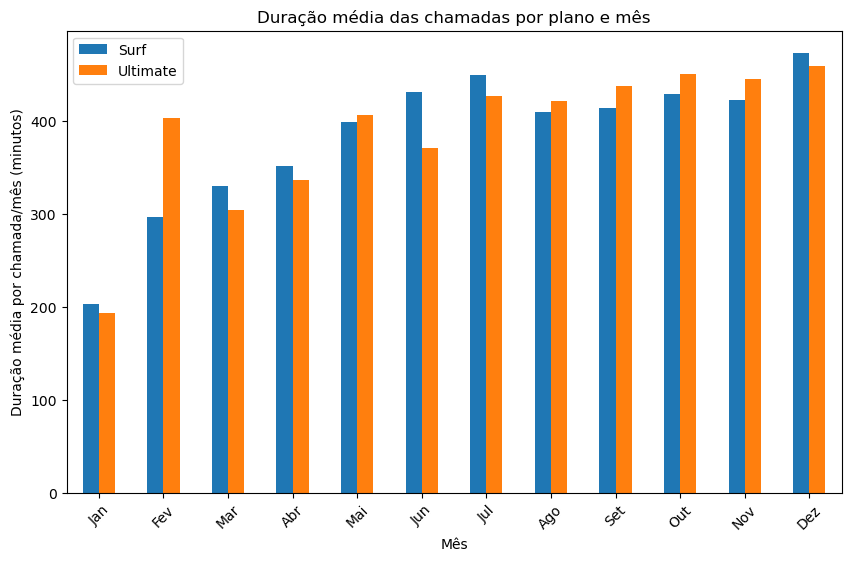

In [38]:
# Comparando a duração média das chamadas de cada plano para cada mês. Criando um gráfico de barras para visualizar o resultado.

# Construindo o gráfico de barras pedido:

# Faremos isso com uma tabela dinâmica:

media_de_internet_por_mes_e_plano = consumo_e_planos.pivot_table(
    index = 'mes',
    columns = 'plan',
    values = 'minutos_gastos',
    aggfunc = 'mean'
).reset_index()

# Renomeando os meses:
meses = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
        7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}

media_de_internet_por_mes_e_plano['mes'] = media_de_internet_por_mes_e_plano['mes'].map(meses)

# A partir dessa tabela, faremos um gráfico de barras para analisar o comportamento em cada plano:
plt.figure(figsize=(10, 6))
media_de_internet_por_mes_e_plano.plot(
    x = 'mes',
    y = ['surf','ultimate'],
    xlabel = 'Mês',
    ylabel = 'Duração média por chamada/mês (minutos)',
    rot = 45,
    title = 'Duração média das chamadas por plano e mês',
    kind = 'bar',
    figsize=(10, 6)
)

plt.legend(['Surf','Ultimate'])
plt.show()

Conclusão: Podemos observar que não há muita variação na média dos minutos gastos pelos usuários em cada plano, por mês. 

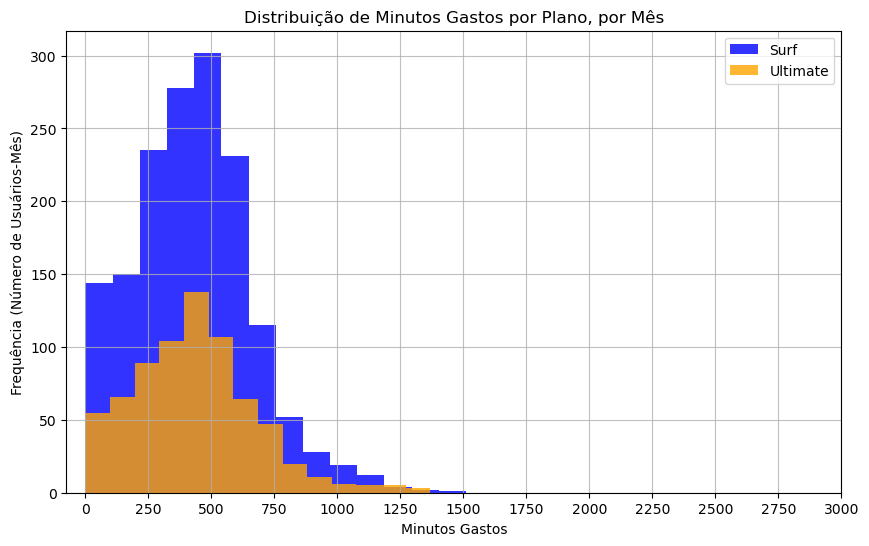

In [39]:
# Comparando o número de minutos que os usuários de cada plano necessitam a cada mês. Construindo um histograma.

# Precisamos analisar 4 colunas de interesse da tabela 'consumo_e_planos'. São elas: 'user_id','mes','minutos_gastos', e 'plan'
cols = ['user_id','mes','minutos_gastos','plan']
tabela_de_interesse_chamadas = consumo_e_planos[cols]

# Precisamos filtrar a 'tabela_de_interesse' por plano:
chamadas_surf = tabela_de_interesse_chamadas[tabela_de_interesse_chamadas['plan'] == 'surf'] # essa tabela é útil para criar a distribuição de minutos gastos no plano 'surf'
chamadas_ultimate = tabela_de_interesse_chamadas[tabela_de_interesse_chamadas['plan'] == 'ultimate'] # E essa fará a mesma coisa para o plano 'ultimate'


# Construindo o histograma:
plt.figure(figsize=(10, 6))
plt.hist(chamadas_surf['minutos_gastos'], bins = 14, alpha=0.8, label='Surf', color='blue')
plt.hist(chamadas_ultimate['minutos_gastos'], bins = 14, alpha=0.8, label='Ultimate', color='orange')
plt.xlabel('Minutos Gastos')
plt.ylabel('Frequência (Número de Usuários-Mês)')
plt.title('Distribuição de Minutos Gastos por Plano, por Mês')
plt.xticks(range(0, 3250, 250))
plt.grid(True, alpha = 0.8)
plt.legend()

plt.show()



O histograma mostra alguns pontos importantes sobre o consumo mensal de minutos nas chamadas pelos usuários em cada plano:
- A moda do histograma do plano surf mostra que os clientes costumam aproveitar os limites de 500 minutos do plano
- Uma boa parte dos usuários do plano surf ultrapassam os limites do plano, bem acima do estimado no plano ultimate (o que mostra que o plano ultimate seria melhor pra esses clientes que para os seus clientes nativos)
- Quase a totalidade dos clientes do plano ultimate não chegam a usar nem metade dos beneficios do plano (3000 minutos)

In [40]:
# Calculando a média e a variância da duração mensal das chamadas
medidas_de_tendencia_central_minutos_chamadas = consumo_e_planos.groupby(['plan'])['minutos_gastos'].agg(['mean','var','std']).reset_index()
medidas_de_tendencia_central_minutos_chamadas


,plan,mean,var,std
0,surf,428.749523,54968.279461,234.453150
1,ultimate,430.450000,57844.464812,240.508762


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_9136\447871401.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tabela_de_interesse_chamadas,


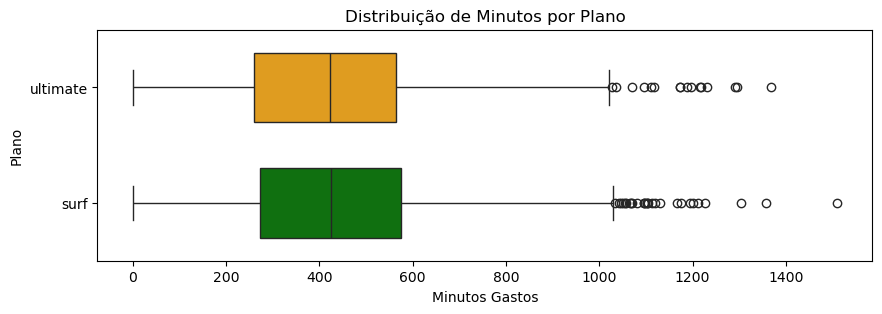

In [41]:
# Fazendo um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
plt.figure(figsize=(10, 3))
sns.boxplot(data=tabela_de_interesse_chamadas, 
           y='plan', 
           x='minutos_gastos',
           palette=['orange', 'green'],  # CORES
           width=0.6)                    # LARGURA

plt.title('Distribuição de Minutos por Plano')
plt.xlabel('Minutos Gastos')
plt.ylabel('Plano')
plt.show()




Conclusão: É possivel perceber que:
- Em ambos os planos, 75% dos usuários costumam gastar menos de 600 minutos por mês.
- A média de minutos gastos em cada plano é quase a mesma (cerca de de 430 minutos), e também a variância.
- O plano surf apresenta pontos isolados que estão mais distantes que os pontos isolados do plano ultimate: Mostrando perfil de cliente do plano surf que consomem mais dados de chamada que os clientes do plano ultimate.
- No geral, vemos duas distribuições bem parecidas. O comportamento dos clientes parece não mudar muito de plano para plano.

### Mensagens

<Figure size 1000x600 with 0 Axes>

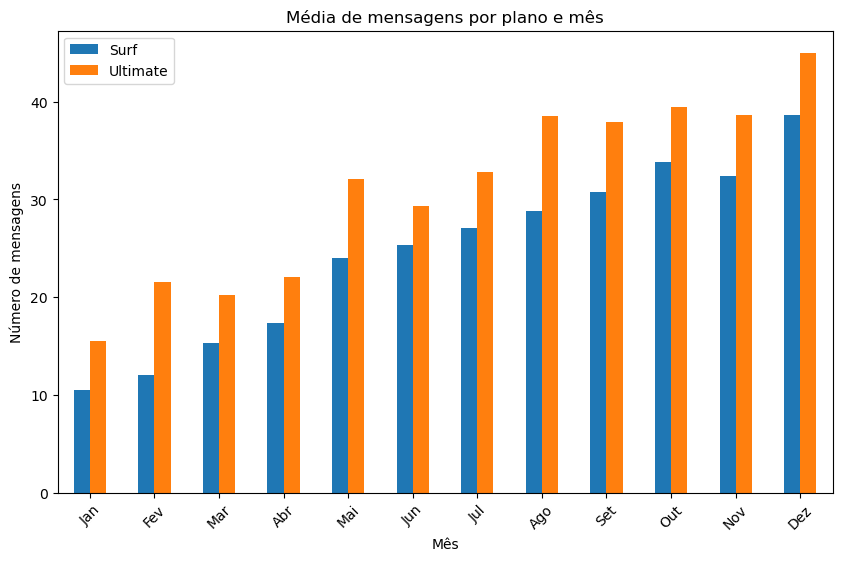

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_9136\3340496267.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tabela_de_interesse_mensagens,


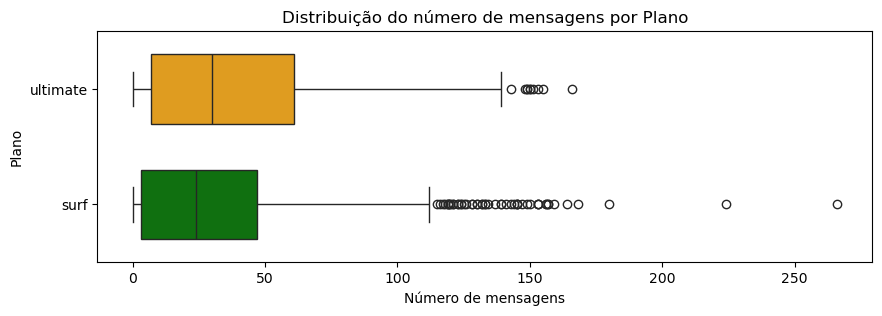

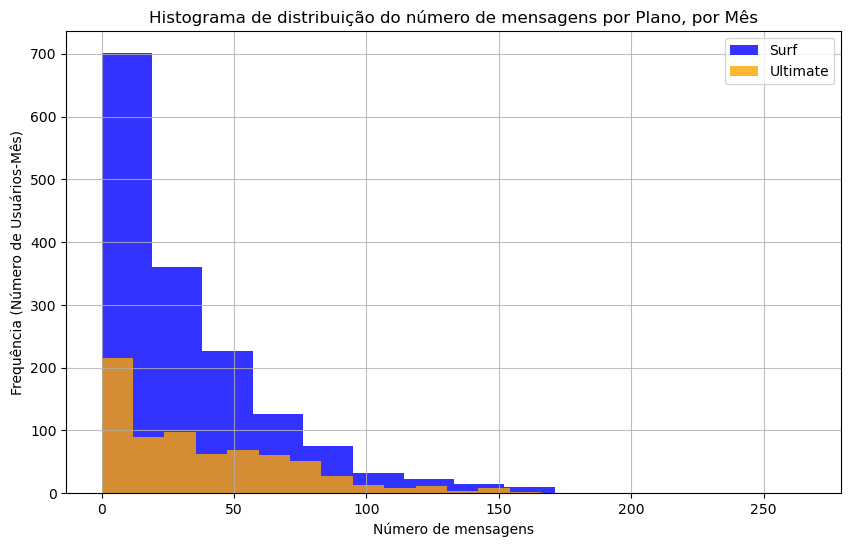

In [42]:
# Comparando o número de mensagens que os usuários de cada plano costumam enviar a cada mês

# CONSTRUINDO UM GRÁFICO DE BARRAS PARA AS MENSAGENS:
# Para isso, precisamos agregar a coluna 'mensagens' por 'mes' e 'plan', na tabela 'consumo_e_planos', usando a média de mensagens.
# Faremos isso com uma tabela dinâmica:
media_de_mensagens_por_mes_e_plano = consumo_e_planos.pivot_table(
    index = 'mes',
    columns = 'plan',
    values = 'mensagens',
    aggfunc = 'mean'
).reset_index()

# Renomeando os meses:
meses = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
        7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}

media_de_mensagens_por_mes_e_plano['mes'] = media_de_mensagens_por_mes_e_plano['mes'].map(meses)

# A partir dessa tabela, faremos um gráfico de barras para analisar o comportamento em cada plano:
plt.figure(figsize=(10, 6))
media_de_mensagens_por_mes_e_plano.plot(
    x = 'mes',
    y = ['surf','ultimate'],
    xlabel = 'Mês',
    ylabel = 'Número de mensagens',
    rot = 45,
    title = 'Média de mensagens por plano e mês',
    kind = 'bar',
    figsize=(10, 6)
)

plt.legend(['Surf','Ultimate'])
plt.show()


# CONNSTRUINDO UM BOXPLOT PARA AS MENSAGENS:
cols = ['user_id','mes','mensagens','plan']
tabela_de_interesse_mensagens = consumo_e_planos[cols]
 
plt.figure(figsize=(10, 3))
sns.boxplot(data=tabela_de_interesse_mensagens, 
           y='plan', 
           x='mensagens',
           palette=['orange', 'green'],  # CORES
           width=0.6)                    # LARGURA

plt.title('Distribuição do número de mensagens por Plano')
plt.xlabel('Número de mensagens')
plt.ylabel('Plano')
plt.show()


# CONSTRUINDO UM HISTOGRAMA PARA AS MENSAGENS:
mensagens_surf = tabela_de_interesse_mensagens[tabela_de_interesse_mensagens['plan'] == 'surf']
mensagens_ultimate = tabela_de_interesse_mensagens[tabela_de_interesse_mensagens['plan'] == 'ultimate']

plt.figure(figsize=(10, 6))
plt.hist(mensagens_surf['mensagens'], bins = 14, alpha=0.8, label='Surf', color='blue')
plt.hist(mensagens_ultimate['mensagens'], bins = 14, alpha=0.8, label='Ultimate', color='orange')
plt.xlabel('Número de mensagens')
plt.ylabel('Frequência (Número de Usuários-Mês)')
plt.title('Histograma de distribuição do número de mensagens por Plano, por Mês')
plt.xticks(range(0, 300, 50))
plt.grid(True, alpha = 0.8)
plt.legend()

plt.show()

In [43]:
# calculando a média, variância e desvio padrão do número de mensagens que os usuários de cada plano costumam enviar a cada mês:
medidas_de_tendencia_central_mensagens = consumo_e_planos.groupby(['plan'])['mensagens'].agg(['mean','var','std']).reset_index()
medidas_de_tendencia_central_mensagens

,plan,mean,var,std
0,surf,31.159568,1126.724522,33.566717
1,ultimate,37.551389,1208.756744,34.767179


Com base na análise da tabela, do histograma e do boxplot acima é possível observar que:
- A quantidade de mensagens de ambos os planos aumenta mês a mês de Janeiro até Dezembro.
- Os planos não apresentam muitas diferenças no consumo do número de mensagens pelos usuários (com o plano ultimate ligeiramente à frente do plano surf, mas não é uma grande diferença), visto que as médias são bem próximas (cerca de 6 mensagens de diferença) e os desvios padrões são praticamente iguais.
- Um fato curioso é que a totalidade dos usuários do plano ultimate não aproveitam as vantagens do plano, visto que não enviam mais que 200 mensagens por mês.
- 75% dos usuários do plano surf usam a faixa de mensagens ofertada pelo plano: de 50 mensagens

In [44]:
# Comparando a quantidade de tráfego de internet consumido pelos usuários por plano.
# Calculando a média de consumo mensal de internet dos usuários em cada plano:
surf = consumo_e_planos[consumo_e_planos['plan'] == 'surf']['internet_mb']/1024
ultimate = consumo_e_planos[consumo_e_planos['plan'] == 'ultimate']['internet_mb']/1024

print(f'A média de consumo de internet mensal do plano surf, em GB, é {round(surf.mean(),2)}. Enquanto a média do plano ultimate é {round(ultimate.mean(),2)}')

A média de consumo de internet mensal do plano surf, em GB, é 16.17. Enquanto a média do plano ultimate é 16.81


In [45]:
# Calculando a variância de consumo mensal de internet dos usuários em cada plano:
print(f'A Variância de consumo de internet mensal do plano surf, em GB, é {round(np.var(surf),2)}. Enquanto a Variância do plano ultimate é {round(np.var(ultimate),2)}')

A Variância de consumo de internet mensal do plano surf, em GB, é 61.2. Enquanto a Variância do plano ultimate é 58.71


Conclusão: A princípio, a média e a variância dos dados nos dizem que não há diferença entre o tráfego de internet usado em cada plano. Investigaremos essa tese mais profundamente nos próximos tópicos

### Internet

<Figure size 1000x600 with 0 Axes>

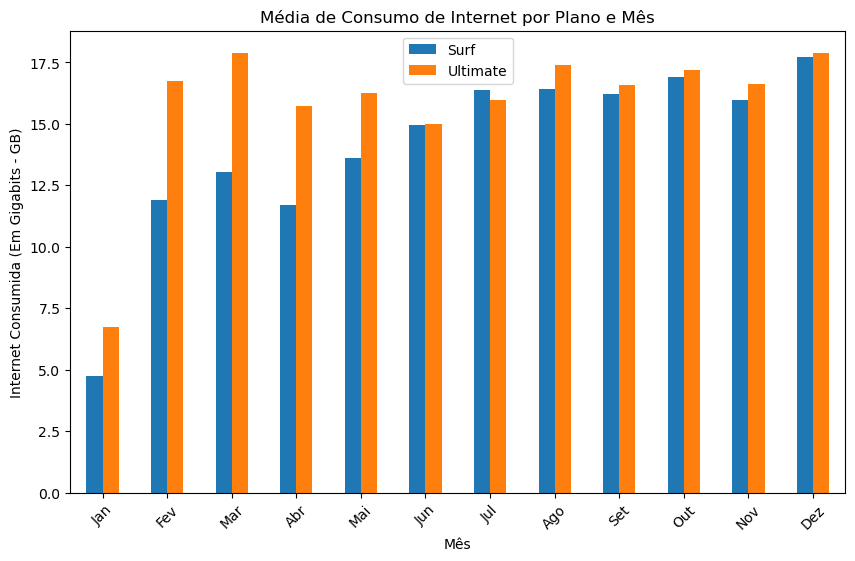

In [46]:

# CONSTRUINDO UM GRÁFICO DE BARRAS PARA O CONSUMO MÉDIO DE INTERNET EM CADA PLANO:

# Faremos isso com uma tabela dinâmica:
consumo_e_planos['internet_mb'] = consumo_e_planos['internet_mb'] / 1024
consumo_e_planos = consumo_e_planos.rename(columns = {'internet_mb':'internet_gb'})

media_de_internet_por_mes_e_plano = consumo_e_planos.pivot_table(
    index = 'mes',
    columns = 'plan',
    values = 'internet_gb',
    aggfunc = 'mean'
).reset_index()

# Renomeando os meses:
meses = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
        7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}

media_de_internet_por_mes_e_plano['mes'] = media_de_internet_por_mes_e_plano['mes'].map(meses)

# A partir dessa tabela, faremos um gráfico de barras para analisar o comportamento em cada plano:
plt.figure(figsize=(10, 6))
media_de_internet_por_mes_e_plano.plot(
    x = 'mes',
    y = ['surf','ultimate'],
    xlabel = 'Mês',
    ylabel = 'Internet Consumida (Em Gigabits - GB)',
    rot = 45,
    title = 'Média de Consumo de Internet por Plano e Mês',
    kind = 'bar',
    figsize=(10, 6)
)

plt.legend(['Surf','Ultimate'])
plt.show()


C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_9136\3465920920.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tabela_de_interesse_internet,


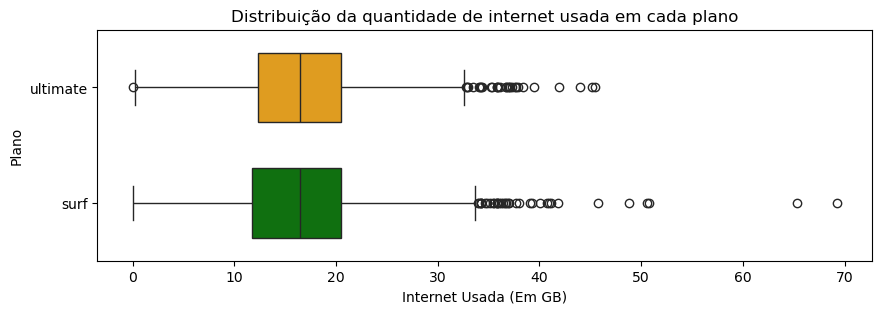

In [47]:
# CONNSTRUINDO UM BOXPLOT PARA A INTERNET CONSUMIDA EM CADA PLANO:
cols = ['user_id','mes','internet_gb','plan']
tabela_de_interesse_internet = consumo_e_planos[cols]
 
plt.figure(figsize=(10, 3))
sns.boxplot(data=tabela_de_interesse_internet, 
           y='plan', 
           x='internet_gb',
           palette=['orange', 'green'],  # CORES
           width=0.6)                    # LARGURA

plt.title('Distribuição da quantidade de internet usada em cada plano')
plt.xlabel('Internet Usada (Em GB)')
plt.ylabel('Plano')
plt.show()


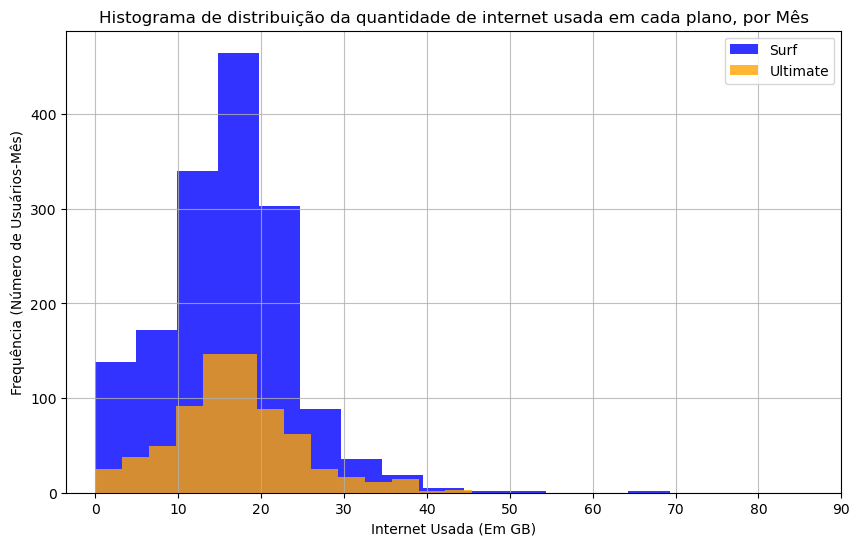

In [48]:
# CONSTRUINDO UM HISTOGRAMA PARA A INTERNET:

internet_surf = tabela_de_interesse_internet[tabela_de_interesse_internet['plan'] == 'surf']
internet_ultimate = tabela_de_interesse_internet[tabela_de_interesse_internet['plan'] == 'ultimate']

plt.figure(figsize=(10, 6))
plt.hist(internet_surf['internet_gb'], bins = 14, alpha=0.8, label='Surf', color='blue')
plt.hist(internet_ultimate['internet_gb'], bins = 14, alpha=0.8, label='Ultimate', color='orange')
plt.xlabel('Internet Usada (Em GB)')
plt.ylabel('Frequência (Número de Usuários-Mês)')
plt.title('Histograma de distribuição da quantidade de internet usada em cada plano, por Mês')
plt.xticks(range(0, 100, 10))
plt.grid(True, alpha = 0.8)
plt.legend()

plt.show()


Conclusão: Tivemos a nossa tese confirmada: Não há muita diferença no comportamento dos usuários quanto ao uso de internet nos dois planos, para não dizer que há uma ligeira diferença nos meses de Janeiro à Maio, com o plano ultimate perceptivamente a frente no consumo.

## Receita

<Figure size 1000x600 with 0 Axes>

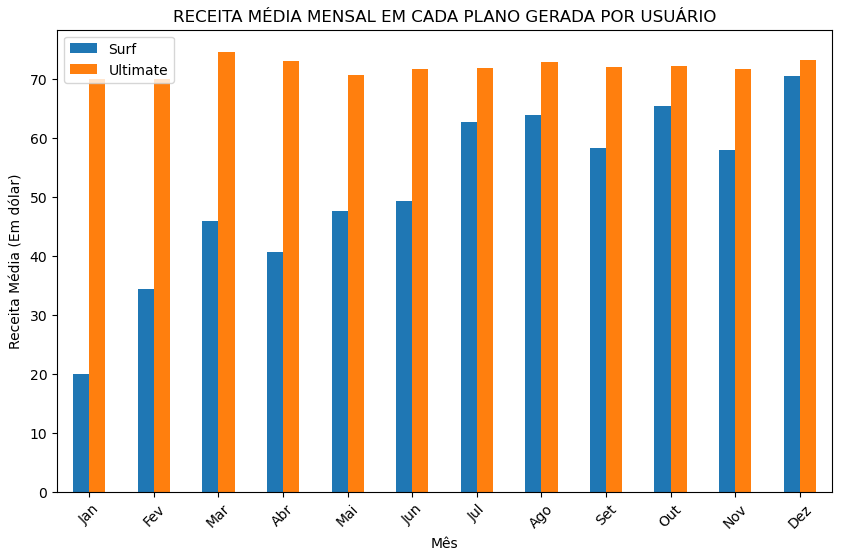

In [49]:
# CONSTRUINDO UM GRÁFICO DE BARRAS PARA A RECEITA MÉDIA MENSAL EM CADA PLANO GERADA POR USUÁRIO:

# Faremos isso com uma tabela dinâmica:

receita_media_mensal_por_plano = consumo_e_planos.pivot_table(
    index = 'mes',
    columns = 'plan',
    values = 'receita_total',
    aggfunc = 'mean'
).reset_index()

# Renomeando os meses:
meses = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
        7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}

receita_media_mensal_por_plano['mes'] = receita_media_mensal_por_plano['mes'].map(meses)


# A partir dessa tabela, faremos um gráfico de barras para analisar o comportamento em cada plano:
plt.figure(figsize=(10, 6))
receita_media_mensal_por_plano.plot(
    x = 'mes',
    y = ['surf','ultimate'],
    xlabel = 'Mês',
    ylabel = 'Receita Média (Em dólar)',
    rot = 45,
    title = 'RECEITA MÉDIA MENSAL EM CADA PLANO GERADA POR USUÁRIO',
    kind = 'bar',
    figsize=(10, 6)
)

plt.legend(['Surf','Ultimate'])
plt.show()

C:\Users\Z4r4k1\AppData\Local\Temp\ipykernel_9136\1254670091.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tabela_de_interesse_receita,


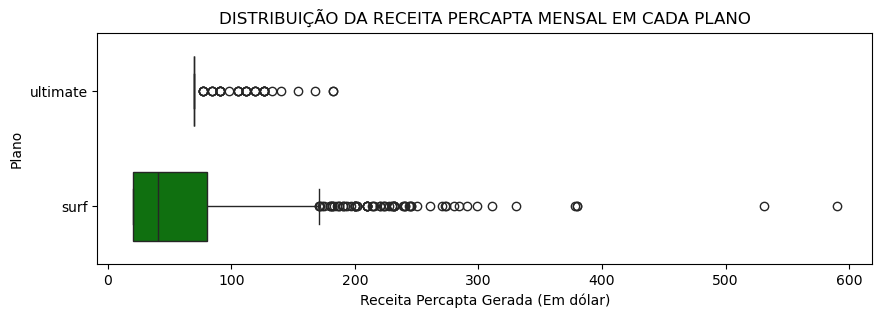

In [50]:
# CONNSTRUINDO UM BOXPLOT PARA OBSERVAR A DISTRIBUIÇÃO DA RECEITA PERCAPTA MENSAL EM CADA PLANO:
cols = ['user_id','mes','receita_total','plan']
tabela_de_interesse_receita = consumo_e_planos[cols]
 
plt.figure(figsize=(10, 3))
sns.boxplot(data=tabela_de_interesse_receita, 
           y='plan', 
           x='receita_total',
           palette=['orange', 'green'],  # CORES
           width=0.6)                    # LARGURA

plt.title('DISTRIBUIÇÃO DA RECEITA PERCAPTA MENSAL EM CADA PLANO')
plt.xlabel('Receita Percapta Gerada (Em dólar)')
plt.ylabel('Plano')
plt.show()

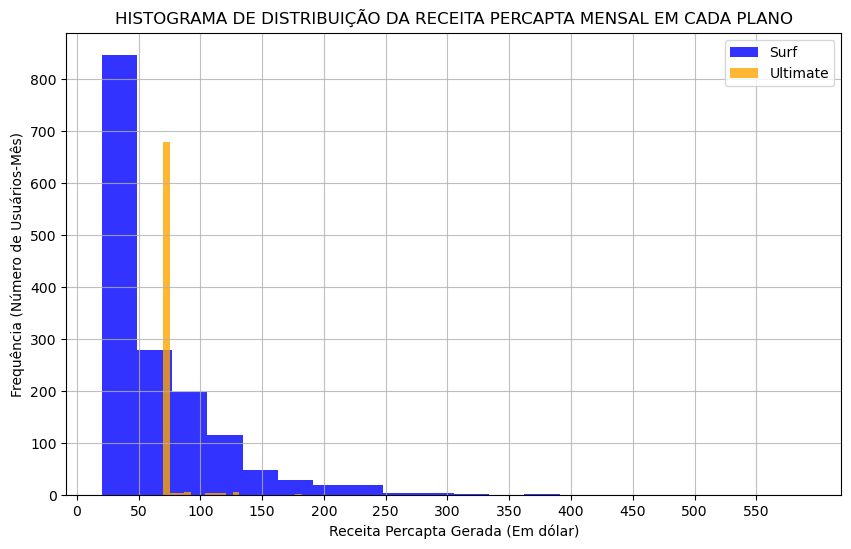

In [51]:
# CONSTRUINDO UM HISTOGRAMA PARA OBSERVAR A DISTRIBUIÇÃO DA RECEITA PERCAPTA MENSAL EM CADA PLANO:

receita_surf = tabela_de_interesse_receita[tabela_de_interesse_receita['plan'] == 'surf']
receita_ultimate = tabela_de_interesse_receita[tabela_de_interesse_receita['plan'] == 'ultimate']

plt.figure(figsize=(10, 6))
plt.hist(receita_surf['receita_total'], bins = 20, alpha=0.8, label='Surf', color='blue')
plt.hist(receita_ultimate['receita_total'], bins = 20, alpha=0.8, label='Ultimate', color='orange')
plt.xlabel('Receita Percapta Gerada (Em dólar)')
plt.ylabel('Frequência (Número de Usuários-Mês)')
plt.title('HISTOGRAMA DE DISTRIBUIÇÃO DA RECEITA PERCAPTA MENSAL EM CADA PLANO')
plt.xticks(range(0, 600, 50))
plt.grid(True, alpha = 0.8)
plt.legend()


plt.show()

In [52]:
# calculando a média, variância e desvio padrão da receita percapta mensal para cada plano:
medidas_de_tendencia_central_receita = consumo_e_planos.groupby(['plan'])['receita_total'].agg(['mean','var','std']).reset_index()
medidas_de_tendencia_central_receita

,plan,mean,var,std
0,surf,60.706408,3067.835152,55.388042
1,ultimate,72.313889,129.848486,11.395108


Conclusão: Existem diferenças consideráveis nas receitas percaptas mensais de ambos os planos:
- O plano ultimate possui um ticket médio maior que o plano surf em cerca de 12 dólares.
- O plano ultimete está bastante concentrado na região dos $72, que é basicamente o seu preço mensal (O que sugere que clientes premium não estão retornando outras receitas), já que o desvio padrão é bem baixo.
- O plano surf se mantém melhor distribuido, com um desvio padrão consideravelmente maior
- O plano ultimate gerou consideravelmente maior preço médio nos 6 primeiros meses do ano, nos 6 meses seguintes essa diferença diminuiu bastante.

## Teste hipóteses estatísticas

Iremos testar a hipótese de que: a receita média dos usuários dos planos Ultimate e Surf são diferentes.

Hipótese nula: A receita média do plano Surf é **IGUAL** da receita média do plano Ultimate.

Hipótese alternativa: A receita média do plano Surf é **DIFERENTE** da receita média do plano Ultimate.

In [53]:
# Testando as hipóteses
# Usaremos um teste bicaudal simples, de valores-p:
media_ultimate = 72.31
alpha = 0.05    # Nível de significância de 5%

results = st.ttest_1samp(receita_surf['receita_total'], media_ultimate) # Irá comparar a média do plano Surf com o plano Ultimate

# Imprimindo o p-valor:
print(f'O p-valor resultante é: {results.pvalue}')

# Comparando o p-valor com o nível de significância:
if results.pvalue < alpha:
    print('❌PODEMOS rejeitar a Hipótese nula. E portanto, NÃO podemos rejeitar a hipótese alternativa')
else:
    print('✅NÃO podemos rejeitar a Hipótese nula. E portanto, PODEMOS rejeitar a hipótese alternativa')

O p-valor resultante é: 2.0618620636875684e-16
❌PODEMOS rejeitar a Hipótese nula. E portanto, NÃO podemos rejeitar a hipótese alternativa


**Conclusão: O p-valor é consideravelmente menor que o nível de significância de 5%, e por isso, PODEMOS rejeitar a Hipótese nula. E portanto, NÃO podemos rejeitar a hipótese alternativa, isto é: Podemos considerar que a receita média dos usuários dos planos Ultimate e Surf são estatisticamente diferentes.**

Agora, iremos testar a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões:

Verificando a lista de cidades:

In [54]:
consumo_e_planos['city'].unique()

array(['Atlanta-Sandy Springs-Roswell, GA MSA',
       'Seattle-Tacoma-Bellevue, WA MSA',
       'Las Vegas-Henderson-Paradise, NV MSA', 'Tulsa, OK MSA',
       'Dallas-Fort Worth-Arlington, TX MSA',
       'San Francisco-Oakland-Berkeley, CA MSA',
       'Grand Rapids-Kentwood, MI MSA',
       'Orlando-Kissimmee-Sanford, FL MSA',
       'San Jose-Sunnyvale-Santa Clara, CA MSA',
       'Cleveland-Elyria, OH MSA',
       'Chicago-Naperville-Elgin, IL-IN-WI MSA', 'Knoxville, TN MSA',
       'New York-Newark-Jersey City, NY-NJ-PA MSA', 'Pittsburgh, PA MSA',
       'Fresno, CA MSA',
       'Washington-Arlington-Alexandria, DC-VA-MD-WV MSA',
       'Indianapolis-Carmel-Anderson, IN MSA', 'Jacksonville, FL MSA',
       'Los Angeles-Long Beach-Anaheim, CA MSA',
       'Omaha-Council Bluffs, NE-IA MSA',
       'Houston-The Woodlands-Sugar Land, TX MSA',
       'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA',
       'Tampa-St. Petersburg-Clearwater, FL MSA',
       'Birmingham-Hoover, AL MSA'

Sabemos quais cidades da lista de cidades disponíveis em 'consumo_e_planos['city'].unique()' estão na região NY-NJ, são elas: 
- 'New York-Newark-Jersey City, NY-NJ-PA MSA',
- 'Buffalo-Cheektowaga, NY MSA', 
- 'Albany-Schenectady-Troy, NY MSA',
- 'Rochester, NY MSA'

Isso irá facilitar a nossa análise

In [55]:
# Para facilitar, criaremos outra coluna categórica na nossa tabela 'consumo_e_planos', para identificar se o usuário é da região NY-Nj, ou de outras regiões:
def classificar_regiao(cidade): # função de classificação
    lista_de_cidades_NY_NJ = [
        'New York-Newark-Jersey City, NY-NJ-PA MSA',
        'Buffalo-Cheektowaga, NY MSA', 
        'Albany-Schenectady-Troy, NY MSA',
        'Rochester, NY MSA'
    ]
    if cidade in lista_de_cidades_NY_NJ:
        return 'NY-NJ'
    else:
        return 'Outras Regiões'

# Criando a nova coluna:
cols = ['user_id','mes','plan','city','regiao','receita_total']
consumo_e_planos['regiao'] = consumo_e_planos['city'].apply(classificar_regiao)

consumo_e_planos[cols].sample(10) # Imprimindo uma amostra da tabela

,user_id,mes,plan,city,regiao,receita_total
1441,1313,12,surf,"San Francisco-Oakland-Berkeley, CA MSA",Outras Regiões,24.20
1101,1232,12,surf,"Chicago-Naperville-Elgin, IL-IN-WI MSA",Outras Regiões,54.41
1892,1405,8,ultimate,"Indianapolis-Carmel-Anderson, IN MSA",Outras Regiões,70.00
1362,1293,8,surf,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",Outras Regiões,50.00
2039,1439,7,surf,"Riverside-San Bernardino-Ontario, CA MSA",Outras Regiões,70.27
1950,1416,10,surf,"Minneapolis-St. Paul-Bloomington, MN-WI MSA",Outras Regiões,40.00
815,1171,2,surf,"Boston-Cambridge-Newton, MA-NH MSA",Outras Regiões,30.00
458,1098,9,surf,"Albany-Schenectady-Troy, NY MSA",NY-NJ,162.97
1046,1220,5,surf,"Cincinnati, OH-KY-IN MSA",Outras Regiões,55.73
1168,1249,6,ultimate,"Cincinnati, OH-KY-IN MSA",Outras Regiões,70.00


In [56]:
# Agora, iremos filtrar essa tabela por região:
mask_1 = consumo_e_planos['regiao'] == 'NY-NJ'
mask_2 = consumo_e_planos['regiao'] == 'Outras Regiões'
ny_nj = consumo_e_planos[mask_1][cols]
outras_regioes = consumo_e_planos[mask_2][cols]

# Imprimindo amostras das tabelas filtradas por região:
print(ny_nj.head())
print('____________________________________________________________________________')
print(outras_regioes.head())

   user_id  mes  plan                                       city regiao  \
56    1014   11  surf  New York-Newark-Jersey City, NY-NJ-PA MSA  NY-NJ   
57    1014   12  surf  New York-Newark-Jersey City, NY-NJ-PA MSA  NY-NJ   
75    1022    5  surf  New York-Newark-Jersey City, NY-NJ-PA MSA  NY-NJ   
76    1022    6  surf  New York-Newark-Jersey City, NY-NJ-PA MSA  NY-NJ   
77    1022    7  surf  New York-Newark-Jersey City, NY-NJ-PA MSA  NY-NJ   

    receita_total  
56          20.00  
57          38.84  
75          20.00  
76         100.00  
77          20.00  
____________________________________________________________________________
  user_id  mes      plan                                   city  \
0    1000   12  ultimate  Atlanta-Sandy Springs-Roswell, GA MSA   
1    1001    8      surf        Seattle-Tacoma-Bellevue, WA MSA   
2    1001    9      surf        Seattle-Tacoma-Bellevue, WA MSA   
3    1001   10      surf        Seattle-Tacoma-Bellevue, WA MSA   
4    1001   11   

Por fim, testaremos nossa hipótese. Utilizaremos o teste da hipótese sobre a igualdade das médias de duas populações:
- Hipótese nula: A receita média dos usuários da área de NY-NJ **NÃO** difere dos usuários das demais regiões;
- Hipótese alternativa: A receita média dos usuários da área de NY-NJ **DIFERE** dos usuários das demais regiões

In [57]:
# Mas primeiro, executaremos o teste de Levene para saber se as variâncias podem ser consideradas iguais ou não:
# H₀: As variâncias são estatisticamente iguais
 
# Separando as receitas por região:
receita_ny_nj = ny_nj['receita_total']
receita_outras_regioes = outras_regioes['receita_total']

# Teste de Levene
statistic_levene, p_value_levene = st.levene(receita_ny_nj, receita_outras_regioes)

print(f"Teste de Levene:")
print(f"Estatística: {statistic_levene:.4f}")
print(f"P-valor: {p_value_levene:.4f}")

# Interpretação
alpha = 0.05    # Nível crítico de significância de 5%
if p_value_levene > alpha:
    print("✅ Variâncias são estatisticamente IGUAIS (não rejeitamos H₀)")
    print("→ Use teste t com variâncias iguais (equal_var=True)")
else:
    print("❌ Variâncias são estatisticamente DIFERENTES (rejeitamos H₀)")
    print("→ Use teste t com variâncias diferentes (equal_var=False)")

Teste de Levene:
Estatística: 5.4286
P-valor: 0.0199
❌ Variâncias são estatisticamente DIFERENTES (rejeitamos H₀)
→ Use teste t com variâncias diferentes (equal_var=False)


In [58]:
# Agora sim podemos fazer o nosso teste de hipóteses, considerando as variâncias diferentes (equal_var=False):

alpha = 0.05    # Nível crítico de significância de 5%

results = st.ttest_ind(receita_ny_nj, receita_outras_regioes)

print(f'p-valor = {results.pvalue}')

# Interpretação:
if results.pvalue < alpha:
    print("❌ A receita média dos usuários da área de NY-NJ DIFERE dos usuários das demais regiões (rejeitamos H₀)")
else: 
    print("✅ A receita média dos usuários da área de NY-NJ NÃO difere dos usuários das demais regiões (não rejeitamos H₀)")

p-valor = 0.10065559377767885
✅ A receita média dos usuários da área de NY-NJ NÃO difere dos usuários das demais regiões (não rejeitamos H₀)


**Conclusão: Com um nível crítico de significância estatística de 5%, concluimos que a receita média dos usuários da área de NY-NJ NÃO difere dos usuários das demais regiões**

## Conclusão Geral

###  Principais Descobertas:
**1. qual plano gera mais receita?**

   O plano Ultimate gera mais receita média por usuário do que o plano Surf.

   Evidências desses resultados:
   
   Análise Descritiva:
   - Receita média mensal por usuário:
   - Ultimate: $\$72.31$ ($desvio_{padrão}$ = $\$11.40$)
     
   - Surf: $\$60.71$ ($desvio_{padrão}$ = $\$55.39$)
     
   - Diferença: O Ultimate gera aproximadamente $\$11.60$ a mais por usuário/mês

   Padrões observados nos gráficos:
   - O histograma mostrou que o Ultimate tem receita concentrada próxima ao valor da mensalidade ($\$70$), indicando que usuários premium raramente excedem os limites do plano
   - O boxplot revelou que o Ultimate tem distribuição mais concentrada, enquanto o Surf apresenta maior variabilidade na receita
   - O gráfico de barras mensal demonstrou que o Ultimate manteve receita consistentemente superior ao longo do ano

   Confirmação Estatística:
   - Teste de hipótese: Rejeitamos a hipótese nula (p-valor < 0.001)
   - Conclusão estatística: As receitas médias dos dois planos são estatisticamente diferentes com 95% de confiança
   - O Ultimate gera receita significativamente maior que o Surf
   -  Mesmo com essa receita extra do Surf, o Ultimate ainda supera em receita média total

    Interpretação do Negócio:
   - Usuários do Ultimate pagam mais pela mensalidade , $\$70$  vs $\$20$, mas raramente geram receita adicional
   - Usuários do Surf, apesar da mensalidade menor, frequentemente excedem os limites, gerando receita variável adicional
   - Mesmo com essa receita extra do Surf, o Ultimate ainda supera em receita média total
     
**2. Resultado sobre diferenças regionais**
  
   Não há diferença significativa na receita entre usuários de NY-NJ e outras regiões:

   Confirmação Estatística:
   - Teste de hipótese: p-valor = 0.101 > 0.05
   - Conclusão: Não rejeitamos H₀ - as receitas médias regionais são estatisticamente iguais
   - Implicação: A estratégia de marketing pode ser uniforme geograficamente

**3. Padrões de comportamento dos usuários**
   
   Os usuários dos dois planos apresentam padrões de consumo similares, mas com aproveitamento diferente dos benefícios:

   Evidências desses resultados observadas nos gráficos:

   - Chamadas: Média similar (~430 minutos) em ambos os planos, mas usuários Surf frequentemente excedem o limite de 500 minutos, enquanto usuários Ultimate raramente usam nem metade dos 3000 minutos disponíveis
   - Mensagens: Comportamento quase idêntico (Surf: 31 mensagens/mês vs Ultimate: 37 mensagens/mês), com usuários Ultimate subutilizando drasticamente o limite de 1000 mensagens
   - Internet: Consumo médio praticamente igual (Surf: 16.17 GB vs Ultimate: 16.81 GB), mostrando que usuários Ultimate não aproveitam os 30 GB disponíveis


###  Decisões Metodológicas:
**1. Como tratei os dados**
   
   Conversões de Tipos de Dados:
   - Convertí user_id para string (object) em todas as tabelas para evitar problemas nas junções de DataFrames e tratar como identificador categórico, não numérico
   - Convertí datas para datetime64 (reg_date, churn_date, call_date, message_date, session_date) para permitir operações temporais adequadas
   - Convertí valores monetários para float (usd_monthly_pay, usd_per_gb) para padronizar como variáveis contínuas
   
   Arredondamento de Chamadas:
   - Implementei a regra de negócio da Megaline: "chamadas são arredondadas para cima ao minuto mais próximo"
   - Criei função maior_inteiro() que arredonda qualquer fração de tempo para o próximo minuto inteiro
   - Mantive coluna original (duration) para preservar dados brutos e criei duration_arredondada para cálculos
   
   Tratamento de Dados de Internet:
   - Convertí MB para GB dividindo por 1024 para facilitar interpretação
   - Apliquei arredondamento para cima conforme regra: "tráfego web é arredondado para cima ao GB mais próximo"
Exemplo: 1.025 MB vira 2 GB conforme política da empresa

   Enriquecimento Temporal:
   - Criei coluna mes em todas as tabelas para agregação mensal
   - Facilitou agrupamentos por usuário e período para análise de consumo

   Estratégia de Junção:
   - Usei merge com how='outer' para não perder dados de usuários em nenhuma tabela
   - Preenchí valores ausentes com 0 para chamadas, minutos, mensagens e internet (interpretando como "não utilizou o serviço no mês")

   Cálculo de Receita:
   - Implementei lógica de cobrança considerando limites dos planos
   - Calculei consumo extra apenas para valores positivos (acima do limite)
   - Somei receita fixa + receita variável para obter receita total por usuário/mês

**2. Por que escolhi determinados testes**
   
   Durante a análise, tomei decisões específicas sobre quais testes estatísticos utilizar, baseando-me nas características dos dados e nos objetivos da pesquisa:

   Para comparar receitas entre planos (Surf vs Ultimate):
 Escolhi o teste t de uma amostra (st.ttest_1samp):

   - Justificativa: Queria comparar se a receita média do plano Surf era estatisticamente diferente de um valor específico (receita média do Ultimate = $72.31)
   - Adequação: Os dados de receita seguem distribuição aproximadamente normal e tenho uma amostra suficientemente grande
   - Configuração: Teste bicaudal com α = 0.05 para detectar diferenças em qualquer direção

   Para comparar receitas entre regiões (NY-NJ vs Outras):
 Primeiro apliquei o Teste de Levene (st.levene):

   - Por quê: Precisava verificar se as variâncias dos dois grupos eram homogêneas antes de escolher o teste t adequado
   - Resultado: p-valor = 0.0199 < 0.05, indicando variâncias estatisticamente diferentes
   - Decisão: Isso me orientou a usar equal_var=False no próximo teste

   Em seguida, usei o teste t de duas amostras independentes (st.ttest_ind):

   - Justificativa: Queria comparar as médias de receita entre dois grupos independentes (NY-NJ vs outras regiões)
   - Configuração: equal_var=False devido ao resultado do teste de Levene
   - Adequação: Grupos independentes, amostras grandes, distribuições aproximadamente normais

###  Implicações para o Negócio:
**1. Recomendações para publicidade**
   
   Com base na análise estatística realizada, posso fazer as seguintes recomendações estratégicas para o orçamento de publicidade:

   *** Foco principal: Plano 
   - Receita superior comprovada: O teste de hipótese confirmou que o Ultimate gera receita estatisticamente maior ($72.31 vs $60.71 por usuário/mês)
   - Previsibilidade de receita: O boxplot mostrou que o Ultimate tem receita concentrada e estável (desvio padrão de apenas $11.40)
   - Margem de contribuição: Diferença de $\$11.60$ por usuário/mês representa 19% mais receita
     
   ***Estratégias Específicas por Segmento:***
   
   Para o Plano Ultimate:

   - Aumentar investimento publicitário: Priorizar 70% do orçamento para atrair novos usuários Ultimate
   - Perfil do cliente ideal: Usuários que valorizam estabilidade e não querem surpresas na conta
   - Mensagem publicitária: "Plano completo sem cobranças extras" - destacar os limites generosos que raramente são ultrapassados

   Para o Plano Surf:

   - Estratégia de conversão: Usar 30% do orçamento para converter usuários Surf que excedem limites para Ultimate
   - Identificação de prospects: O histograma mostrou que muitos usuários Surf ultrapassam os 500 minutos inclusos
   - Mensagem direcionada: "Pare de pagar taxas extras - migre para o Ultimate"

   ***Distribuição Geográfica:***
   
   Estratégia uniforme recomendada:
   - Base estatística: O teste de hipótese (p-valor = 0.101) comprovou que não há diferença significativa entre NY-NJ e outras regiões
   - Implicação prática: Distribuir orçamento publicitário proporcionalmente à população, sem concentração regional específica
   - Eficiência de custos: Evitar sobrecarga de investimento em regiões específicas

   ***Oportunidades Identificadas:***
   
   Usuários Surf com alto consumo:
   
   - Evidência: Gráficos mostraram usuários Surf gerando receitas de até $\$500$/mês por excesso de uso
   - Ação: Campanhas direcionadas para migração: "Economize migrando para Ultimate"

   Subutilização do Ultimate:
   - Evidência: Usuários Ultimate raramente usam nem metade dos benefícios (3000 minutos, 1000 mensagens, 30GB)
   - Ação: Campanhas educativas sobre benefícios inclusos para justificar o valor premium